## Algoritmo do Perceptron

In [1]:
# Importação das bibliotecas bases

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [172]:
class Perceptron:
    def __init__(self, learning_rate=None, epochs=None, seed=None):
        self.weights = None
        self.errors_history = []
        self.epochs = epochs
        self.learning_rate = learning_rate

    def activation_function(self, u):
        '''Função de ativação sinal'''
        return np.where(u >= 0, 1, -1)

    def fit(self, X: np.array, y:np.array):
        '''Algoritmo de Treinamento'''

        n_features, k_samples = X.shape

        # Adiciona bias no vetor de entradas X
        X = np.vstack([np.ones((1, k_samples)), X])

        self.weights = np.random.randn(X.shape[0]) * 0.01 # vetor de pesos gerados com valores pequenos aleatórios, incluindo o bias

        for epoch in range(self.epochs):
            errors_count = 0

            for k in range(k_samples):
                x_k = X[:, k]
                d_k = y[0, k]

                u = self.weights.T @ x_k
                y_pred = self.activation_function(u)

                error = d_k - y_pred

                if error != 0: 
                    self.weights += self.learning_rate * (error) * x_k
                    errors_count += 1

            self.errors_history.append(errors_count / k_samples)

            if errors_count == 0:
                break

        return self.weights, epoch + 1, self.errors_history

    def predict(self, X:np.array):
        '''Algoritmo de Teste'''
        k_samples = X.shape[1]
        X = np.vstack([np.ones((1, k_samples)), X])
        u = self.weights.T @ X
        return self.activation_function(u)

    def accuracy(self, X:np.array, y:np.array):
        return np.mean(self.predict(X) == y)

#### Gráfico da Evolução dos Erros de Classificação

In [173]:
def plot_error_history(errors, title=None):
    plt.figure(figsize=(10, 6))
    plt.plot(errors, marker='o')
    plt.title(title)
    plt.xlabel('Épocas')
    plt.ylabel('Erro de classificação')
    plt.grid(True)
    plt.show()

### Gráfico da Fronteira de Decisão para dois atributos

In [174]:
def plot_decision_boundary(X, y, model, title=""):
    
    X = np.array(X)
    y = np.array(y).flatten()

    plt.figure(figsize=(10, 6))

    for label in np.unique(y):
        plt.scatter(
            X[0, y == label],
            X[1, y == label],
            label=f"Classe {label}"
        )

    w0, w1, w2 = model.weights # Pesos aprendidos pelo Perceptron com os dados de treinamento

    x1_vals = np.linspace(X[0, :].min(), X[0, :].max(), 100)

    if w2 != 0:
        x2_vals = -(w0 + w1 * x1_vals) / w2
        plt.plot(x1_vals, x2_vals, 'k--', label="Fronteira")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

## Dataset 1

* Realizar o treinamento e teste para taxa de aprendizado 0.1 e com 100 épocas. Aqui foi utilizado uma seed 42 para gerar os pesos iniciais aleatoriamente.

#### Treinamento

In [175]:
df_train1 = pd.read_csv('train_dataset1.csv')
X_train1 = df_train1.drop('label', axis=1).values.T
y_train1 = df_train1['label'].values.reshape(1, -1)

In [176]:
model = Perceptron(learning_rate=0.1, epochs=100, seed=42)
weights, epochs_trained, errors = model.fit(X_train1, y_train1)

print("Pesos:", weights)
print("Épocas:", epochs_trained)
print("Acurácia:", model.accuracy(X_train1, y_train1))

Pesos: [ 0.59996283 -1.38458652  1.49763567]
Épocas: 100
Acurácia: 0.9785714285714285


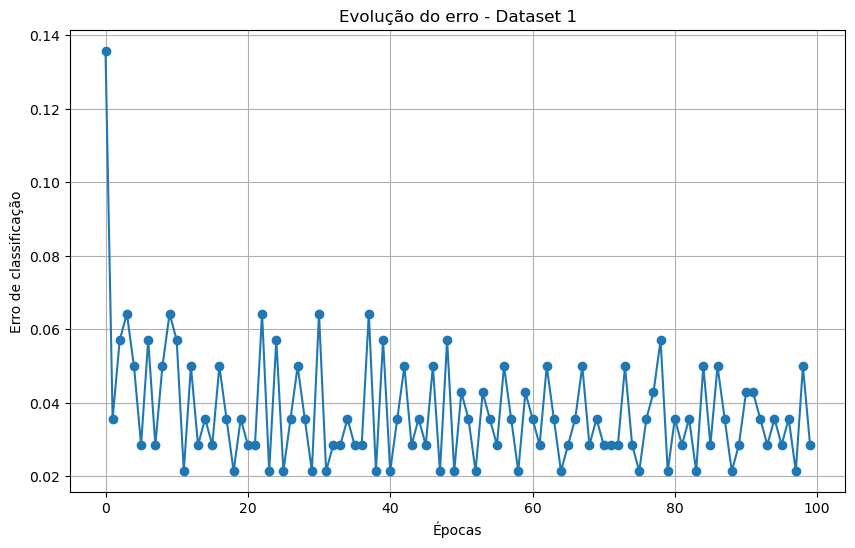

In [177]:
plot_error_history(model.errors_history, title="Evolução do erro - Dataset 1")

* Pelo gráfico, percebe-se que o erro inicial diminui drasticamente, devido à alta taxa de aprendizado. Além disso, como o erro já é bem baixo, ocorre uma oscilação devido às atualizações para otimizar os pesos do modelo. Entretanto, este erro abaixo de 10% mostra que o modelo está conseguindo aprender e, possivelmente os dados são linearmente separáveis.

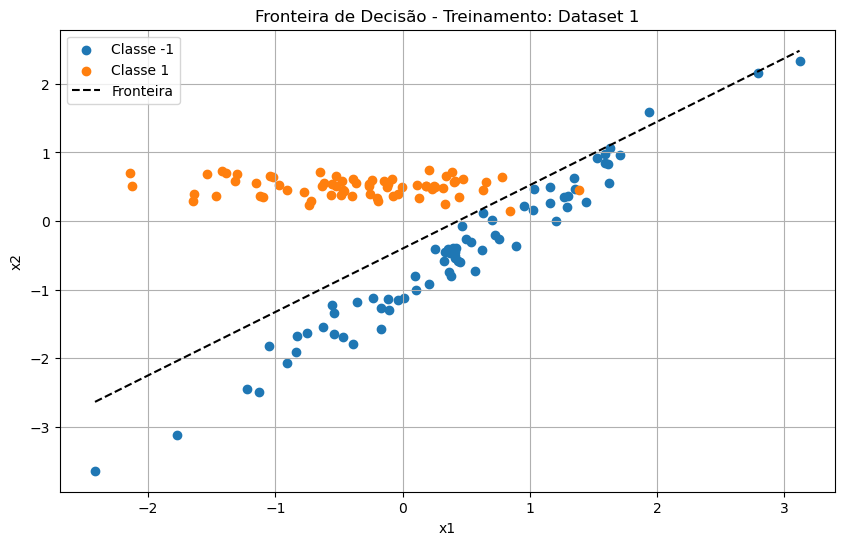

In [178]:
plot_decision_boundary(X_train1, y_train1, model, title='Fronteira de Decisão - Treinamento: Dataset 1')

* Este gráfico mostra que o modelo de fato aprendeu como otimizar os dados de treinamento e que estes são linearmente separáveis.

#### Teste

In [179]:
df_test1 = pd.read_csv('test_dataset1.csv')
X_test1 = df_test1.drop('label', axis=1).values.T
y_test1 = df_test1['label'].values.reshape(1, -1)

In [180]:
print("Acurácia Treinamento:", model.accuracy(X_train1, y_train1))
print("Acurácia Teste:", model.accuracy(X_test1, y_test1))

Acurácia Treinamento: 0.9785714285714285
Acurácia Teste: 0.9333333333333333


* Como as acurácias de treino e teste são próximas, o modelo apresenta boa generalização, indicando que não sofreu overffiting na fase de treinamento.

* Agora, podemos encontrar a fronteira que separa os dados de Teste

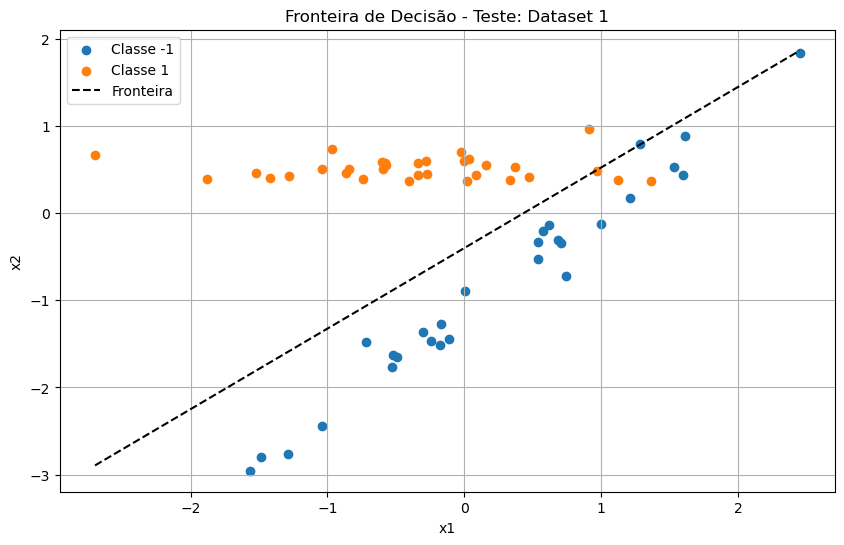

In [181]:
plot_decision_boundary(X_test1, y_test1, model, "Fronteira de Decisão - Teste: Dataset 1")

* Por fim, temos um modelo consistente e, mais importante, uma classe Perceptron capaz de lidar com $k$ entradas de dados com $n$ atributos distintos, para diferentes taxas de aprendizado, épocas e bias gerados aleatoriamente.

---

## Dataset 2

* Realizar o treinamento e teste para taxa de aprendizado 0.1 e com 100 épocas. Aqui foi utilizado uma seed 42 para gerar os pesos iniciais aleatoriamente.

#### Treinamento

In [182]:
df_train2 = pd.read_csv('train_dataset2.csv')
X_train2 = df_train2.drop('label', axis=1).values.T
y_train2 = df_train2['label'].values.reshape(1, -1)

In [183]:
model = Perceptron(learning_rate=0.1, epochs=100, seed=42)
weights, epochs_trained, errors = model.fit(X_train2, y_train2)

print("Pesos:", weights)
print("Épocas:", epochs_trained)
print("Acurácia:", model.accuracy(X_train2, y_train2))

Pesos: [-0.00775851  0.24154685 -0.07706111]
Épocas: 100
Acurácia: 0.4514285714285714


* Percebe-se que o modelo aqui apresenta baixa acurácia quando comparado ao Dataset 1, o que nos dá uma certa intuição de quê o modelo não está aprendendo tão bem quanto antes, sendo relevante  graficar o erro de classificação ao decorrer das épocas.

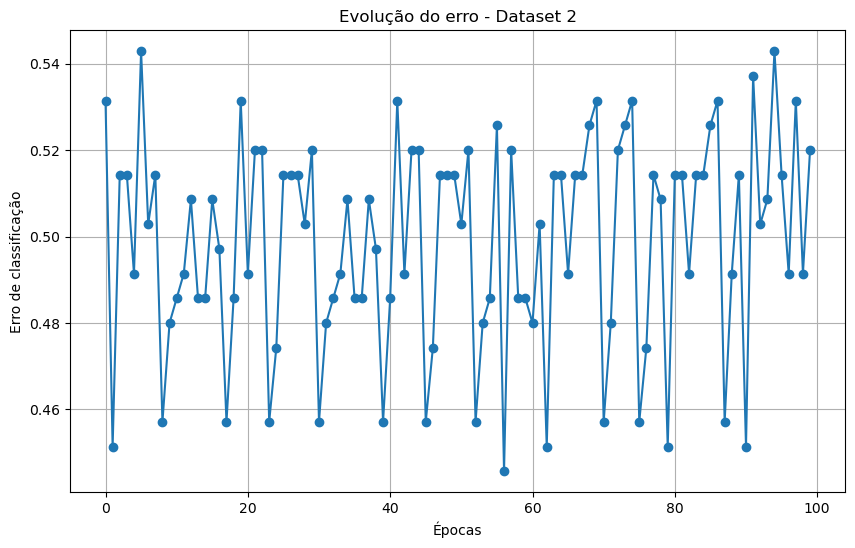

In [184]:
plot_error_history(model.errors_history, title="Evolução do erro - Dataset 2")

* A falta de convergência do erro e a oscilação ao longo das épocas indica ausência de convergência do algoritmo. Como o Perceptron converge apenas para conjuntos linearmente separáveis, isso sugere que o dataset não é linearmente separável.

* Utilizando a função plot_decision_boundary() para encontrar a reta de decisão que separa os dados:

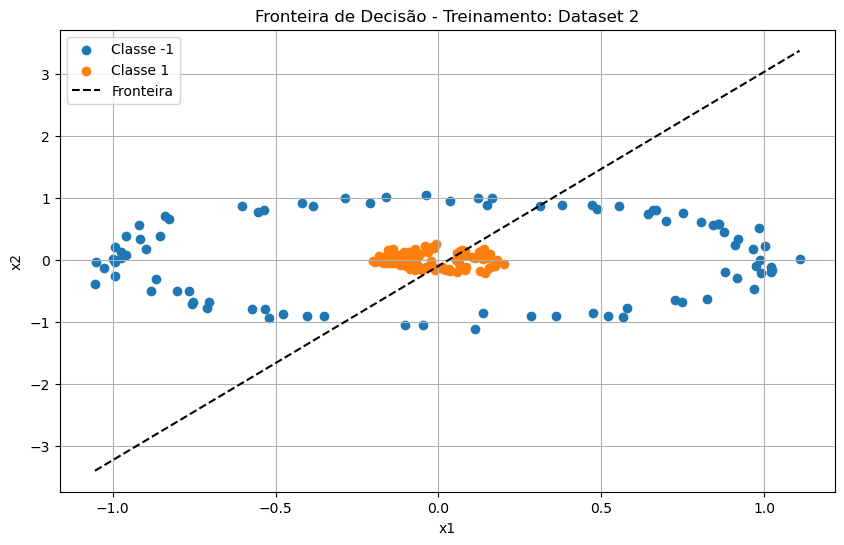

In [185]:
plot_decision_boundary(X_train2, y_train2, model, "Fronteira de Decisão - Treinamento: Dataset 2")

$\Rightarrow$ Neste gráfico fica evidente que trata-se de um dataset não linearmente separável. 

#### Teste

In [186]:
df_test2 = pd.read_csv('test_dataset2.csv')
X_test2 = df_test2.drop('label', axis=1).values.T
y_test2 = df_test2['label'].values.reshape(1, -1)

In [187]:
print("Acurácia:", model.accuracy(X_test2, y_test2))

Acurácia: 0.5466666666666666


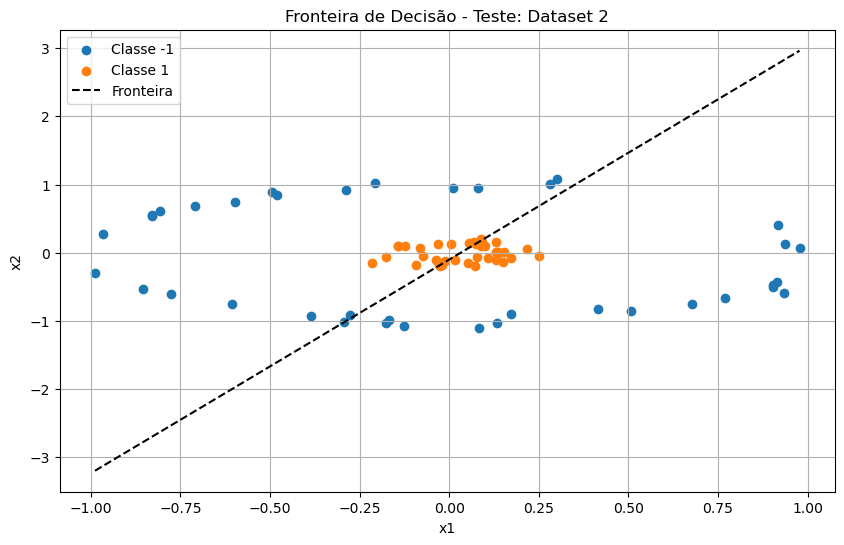

In [188]:
plot_decision_boundary(X_test2, y_test2, model, "Fronteira de Decisão - Teste: Dataset 2")

* Podemos perceber, portanto, que o modelo não consegue realizar uma boa classificação dos dados, pois converge para uma solução aproximada, mas não consegue encontrar uma fronteira linear que separe as classes, já que trata-se de um dataset não lineramente separável.

---

## Dataset 3

In [189]:
df_train3 = pd.read_csv('train_dataset3.csv')
X_train3 = df_train3.drop('label', axis=1).values.T
y_train3 = df_train3['label'].values.reshape(1, -1)

In [190]:
df_test3 = pd.read_csv('test_dataset3.csv')
X_test3 = df_test3.drop('label', axis=1).values.T
y_test3 = df_test3['label'].values.reshape(1, -1)

### Experimento 1: 100 épocas e taxa de aprendizado igual a 0.1

In [191]:
model = Perceptron(learning_rate=0.1, epochs=100, seed=42)
weights, epochs_trained, errors = model.fit(X_train3, y_train3)

print("Pesos:", model.weights)
print("Épocas:", model.epochs)
print("Acurácia Treinamento:", model.accuracy(X_train3, y_train3))
print("Acurácia Teste:", model.accuracy(X_test3, y_test3))


Pesos: [ 0.19818205 -0.19908348 -0.45770887 -0.0161489  -0.51809232  0.58085189
 -0.33028911  0.27011495  0.28660855 -0.12049892  1.92247228]
Épocas: 100
Acurácia Treinamento: 0.8979591836734694
Acurácia Teste: 0.8095238095238095


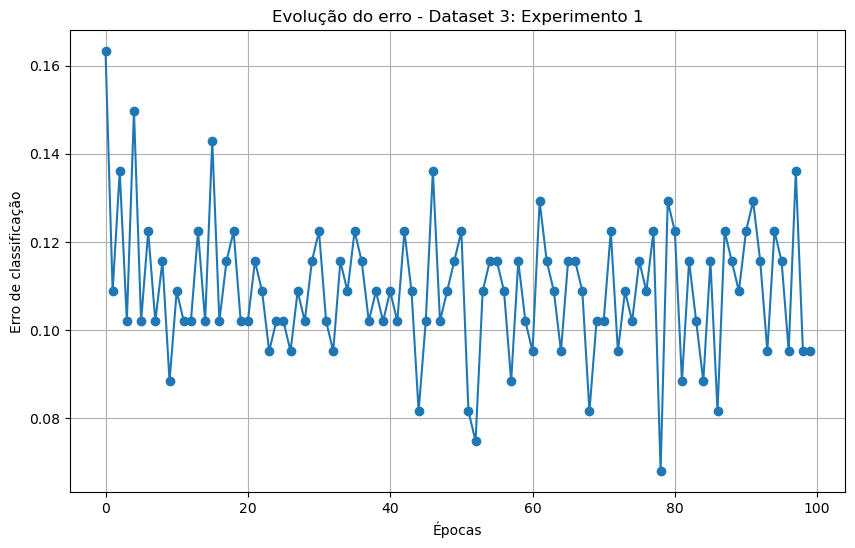

In [192]:
plot_error_history(model.errors_history, title="Evolução do erro - Dataset 3: Experimento 1")

$\Rightarrow$ O Experimento 1 mostrou que, o erro está convergindo para zero, além das acurácias para os dados de Treinamento e Teste serem próximas, mostrando que o modelo não sofreu overffiting e está tentando otimizar os pesos para estes hiperparâmetros.

### Experimento 2: 100 épocas e taxa de aprendizado igual a 0.001

In [193]:
model = Perceptron(learning_rate=0.001, epochs=100, seed=42)
weights, epochs_trained, errors = model.fit(X_train3, y_train3)

print("Pesos:", model.weights)
print("Épocas:", model.epochs)
print("Acurácia Treinamento:", model.accuracy(X_train3, y_train3))
print("Acurácia Teste:", model.accuracy(X_test3, y_test3))


Pesos: [-0.00113075 -0.00107314 -0.00438323 -0.00225484 -0.00584649  0.00595775
 -0.00253973 -0.00234455  0.00426724  0.00093255  0.02314691]
Épocas: 100
Acurácia Treinamento: 0.8707482993197279
Acurácia Teste: 0.8253968253968254


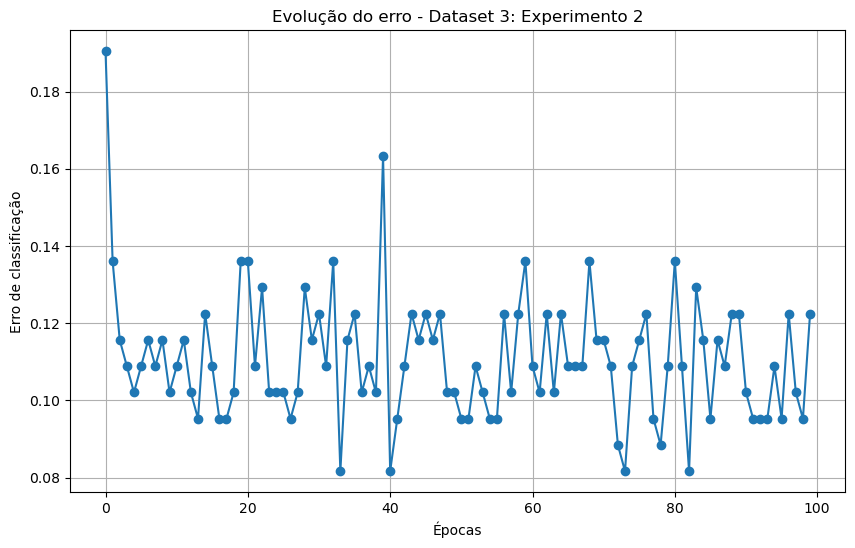

In [194]:
plot_error_history(model.errors_history, title="Evolução do erro - Dataset 3: Experimento 2")

$\Rightarrow$ Aqui, com o Experimento 2 percebe-se não houve mudanças significativas na redução do erro quando comparado ao Experimento 1. Entretanto, podemos perceber uma menor amplitude de oscilação do erro e uma menor diferença entre as acurácias dos dados de Treinamento e Teste, o que possivelmente indica uma melhora na generalização do modelo.

### Experimento 3: 100 épocas e taxa de aprendizado igual a 0.0001

In [195]:
model = Perceptron(learning_rate=0.0001, epochs=100, seed=42)
weights, epochs_trained, errors = model.fit(X_train3, y_train3)

print("Pesos:", model.weights)
print("Épocas:", model.epochs)
print("Acurácia Treinamento:", model.accuracy(X_train3, y_train3))
print("Acurácia Teste:", model.accuracy(X_test3, y_test3))

Pesos: [ 7.53080910e-05 -1.50952463e-04 -3.95944433e-04 -4.13583157e-04
 -1.65298207e-04 -4.07916577e-05 -1.44051232e-04 -1.92246818e-04
  7.96000303e-04  2.74884243e-05  2.61643389e-03]
Épocas: 100
Acurácia Treinamento: 0.9319727891156463
Acurácia Teste: 0.873015873015873


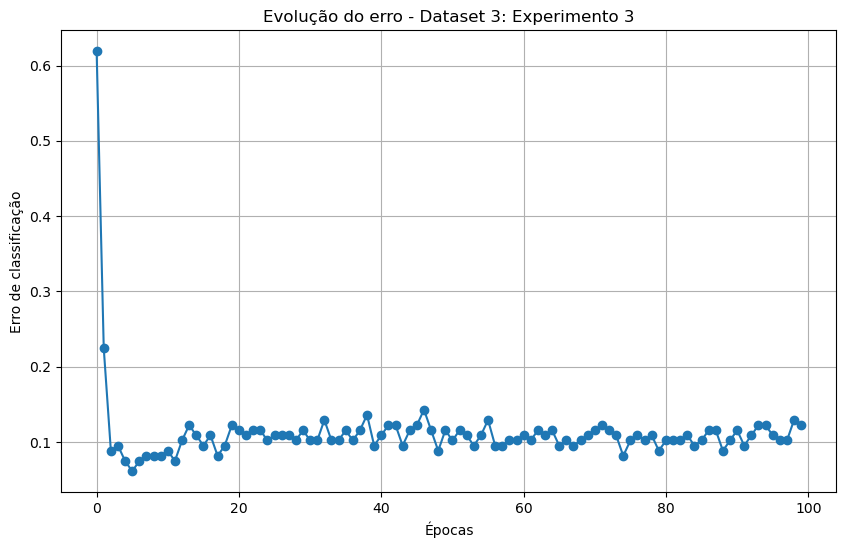

In [196]:
plot_error_history(model.errors_history, title="Evolução do erro - Dataset 3: Experimento 3")

$\Rightarrow$ Comparando o Experimento 3 com os Experimento 1 e 2, podemos perceber que o modelo está convergindo para uma otimização dos parâmetros, porém ainda assim apresenta um erro médio em torno de 10%. Isto mostra que o dataset possui uma estrutura complexa e possivelmente não linear.

### Experimento 4: 200 épocas e taxa de aprendizado igual a 0.1

In [197]:
model = Perceptron(learning_rate=0.1, epochs=200, seed=42)
weights, epochs_trained, errors = model.fit(X_train3, y_train3)

print("Pesos:", model.weights)
print("Épocas:", model.epochs)
print("Acurácia Treinamento:", model.accuracy(X_train3, y_train3))
print("Acurácia Teste:", model.accuracy(X_test3, y_test3))

Pesos: [ 0.18905449  0.35840151 -0.47657687 -0.31508523 -0.80685047  0.44012121
 -0.21655487  0.10659745  0.30956102 -0.01392048  2.26477315]
Épocas: 200
Acurácia Treinamento: 0.8979591836734694
Acurácia Teste: 0.8095238095238095


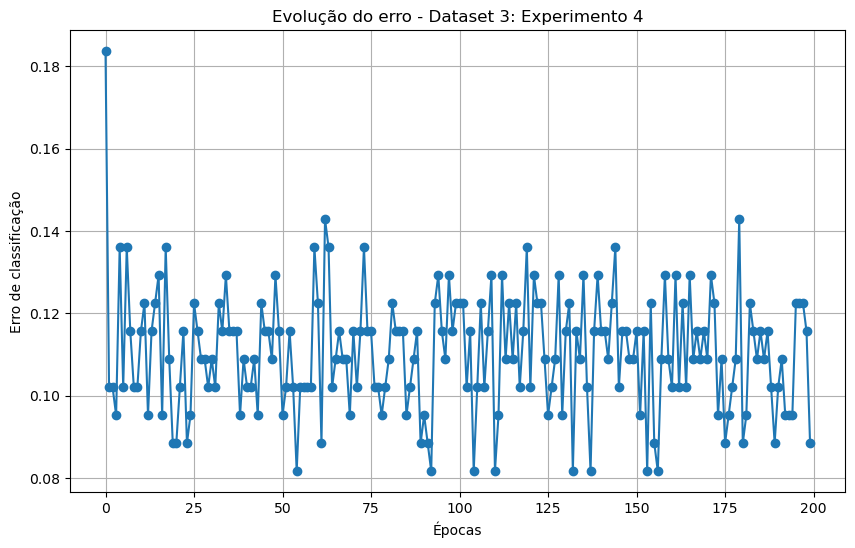

In [198]:
plot_error_history(model.errors_history, title="Evolução do erro - Dataset 3: Experimento 4")

$\Rightarrow$ Este experimento é semelhante ao Experimento 1, mas com uma maior amplitude de oscilação nos erros. Nota-se também que aumentar o número de épocas apenas aumentou o número de iterações do modelo, mas ajudou a convergir para a mesma taxa de aprendizado.

### Experimento 5: 200 épocas e taxa de aprendizado igual a 0.001

In [199]:
model = Perceptron(learning_rate=0.001, epochs=200, seed=42)
weights, epochs_trained, errors = model.fit(X_train3, y_train3)

print("Pesos:", model.weights)
print("Épocas:", model.epochs)
print("Acurácia Treinamento:", model.accuracy(X_train3, y_train3))
print("Acurácia Teste:", model.accuracy(X_test3, y_test3))

Pesos: [-7.96171311e-04  3.58690489e-05 -7.67468527e-03 -1.01439556e-03
 -4.97480391e-03  5.61769751e-03 -3.50209658e-03  2.11119411e-03
  4.39063695e-03 -1.93770462e-03  2.03600808e-02]
Épocas: 200
Acurácia Treinamento: 0.8843537414965986
Acurácia Teste: 0.8095238095238095


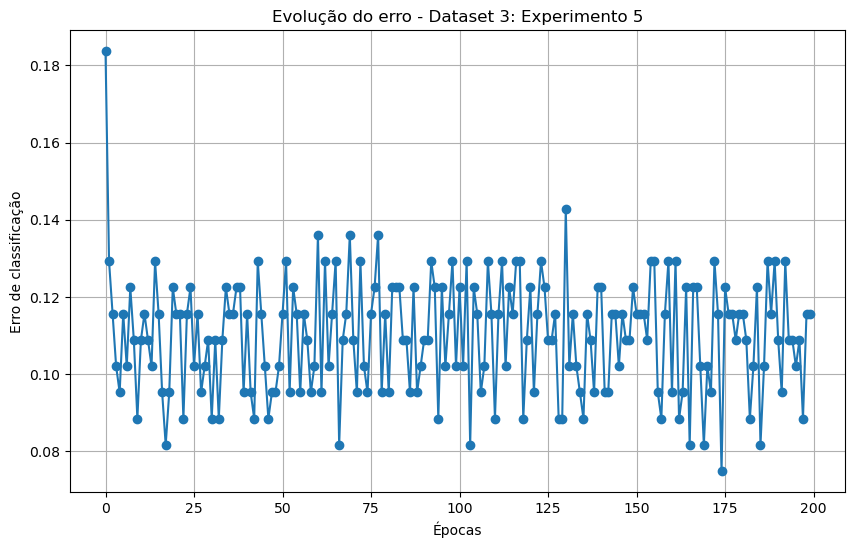

In [200]:
plot_error_history(model.errors_history, title="Evolução do erro - Dataset 3: Experimento 5")

$\Rightarrow$ Comparando com o Experimento 4, ao diminuir a taxa de aprendizado houve uma diminuição na amplitude de oscilação dos erros, indicando uma melhor convergência para a otimização dos pesos.

### Experimento 6: 200 épocas e taxa de aprendizado igual a 0.0001

In [201]:
model = Perceptron(learning_rate=0.0001, epochs=200, seed=42)
weights, epochs_trained, errors = model.fit(X_train3, y_train3)

print("Pesos:", model.weights)
print("Épocas:", model.epochs)
print("Acurácia Treinamento:", model.accuracy(X_train3, y_train3))
print("Acurácia Teste:", model.accuracy(X_test3, y_test3))

Pesos: [ 9.61865472e-05 -9.43278947e-05 -6.43064148e-04 -5.89329244e-04
 -4.34280217e-04  4.16252172e-04  2.95117888e-04  1.06694860e-04
  7.27046308e-04 -3.00768654e-04  2.18642111e-03]
Épocas: 200
Acurácia Treinamento: 0.9047619047619048
Acurácia Teste: 0.8253968253968254


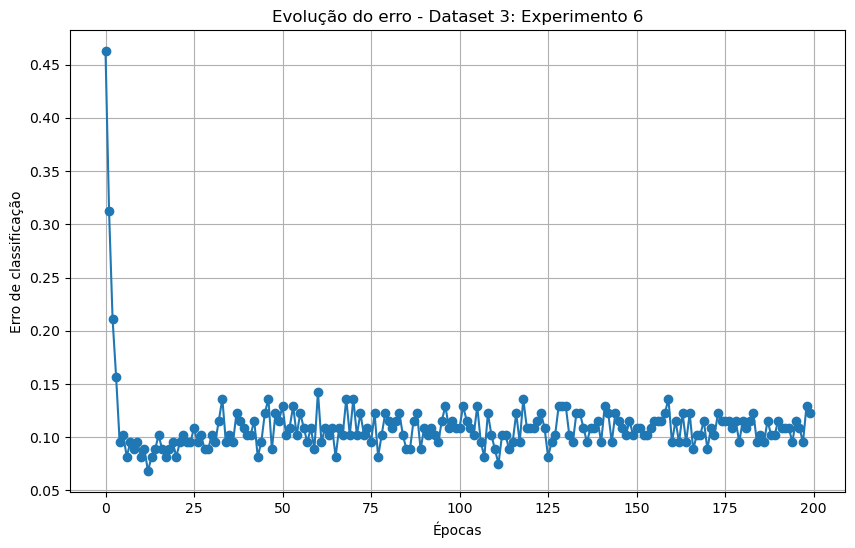

In [202]:
plot_error_history(model.errors_history, title="Evolução do erro - Dataset 3: Experimento 6")

$\Rightarrow$ Por fim, comparando o Experimento 6 com os Experimentos 4 e 5, nota-se uma melhor convergência por parte do modelo. Além disso, podemos compará-lo diretamente com o Experimento 3 e notar que, a redução do erro inicial foi melhor, entretanto, ambos convergem semelhantemente para um erro médio em torno de 10%.

### Conclusão Final Dataset 3

* Os experimentos mostraram atráves da acurácia que o modelo é capaz de generalizar bem os dados deste dataset, de maneira a otimizar os pesos à depender da escolha dos hiperparâmetros. Além disso, as acurácias próximas para os dados de Treinamento e Teste em todos os experimentos mostram que não houve overffiting por parte do modelo. Entretanto, as oscilações do erro de classificação ao longo das épocas indica que os dados possuem uma estrutura mais complexa, possivelmente não linear, dificultando a convergência do algoritmo.